# 📘 K-Means Clustering
## Implementing K-Means on a Dataset
## Model Evaluation, Limitations & Use Cases

---

### Why this notebook?
By the end of this notebook, you will be able to:
- Apply K-Means to real data
- Understand what each parameter does
- Visualize clusters clearly
- Evaluate clustering quality
- Know when **not** to use K-Means


## 🔹 Section 1: Import Necessary Libraries


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Explanation
- NumPy and Pandas for data handling
- Matplotlib and Seaborn for visualization
- KMeans from sklearn does the clustering
- StandardScaler is critical because K-Means uses distance
- Silhouette score helps us evaluate clustering quality

> If you skip scaling, K-Means will happily lie to you.


## 🔹 Section 2: Load and Understand the Dataset


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [32]:
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

We will **pretend we do not know** the species labels and focus only on feature-based grouping.


## 🔹 Section 3: Select Features for Clustering


In [7]:
X_petal = df[["petal_length", "petal_width"]]
X_petal.head()


,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [9]:
X_sepal = df[["sepal_length", "sepal_width"]]
X_petal.head()


,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


We use only two features so clusters are easy to visualize and understand.


## 🔹 Section 4: Feature Scaling (Non-Negotiable)


In [11]:
#Scaling
scaler = StandardScaler()
X_sepal_scaled = scaler.fit_transform(X_sepal)
X_petal_scaled = scaler.fit_transform(X_petal)

> K-Means measures distance.
> Distance cares about scale.
> Therefore, scaling is mandatory.


## 🔹 Section 5: Implementing K-Means


In [13]:
#Selecting value of K
k = 3 

In [15]:
#Implementing K-Means
kmeans_sepal = KMeans(
    n_clusters=k,
    init="k-means++",
    max_iter=300,
    random_state=42
)
kmeans_petal = KMeans(
    n_clusters=k,
    init="k-means++",
    max_iter=300,
    random_state=42
)

In [ ]:
#Data points: 1,2,3,10,11,12
#k=2
#m1=1, m2=10



In [17]:
#Fitting the model
kmeans_sepal.fit(X_sepal_scaled)
kmeans_petal.fit(X_sepal_scaled)

C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

## 🔹 Section 6: Getting Cluster Assignments


In [19]:
#Getting Cluster Assignments
labels_sepal = kmeans_sepal.labels_
labels_petal = kmeans_petal.labels_


In [28]:
df["cluster_sepal"] = labels_sepal
df["cluster_petal"] = labels_petal
df.head(150)

,sepal_length,sepal_width,petal_length,petal_width,species,cluster_sepal,cluster_petal
0,5.1,3.5,1.4,0.2,setosa,2,2
1,4.9,3.0,1.4,0.2,setosa,2,2
2,4.7,3.2,1.3,0.2,setosa,2,2
3,4.6,3.1,1.5,0.2,setosa,2,2
4,5.0,3.6,1.4,0.2,setosa,2,2
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,0,0
146,6.3,2.5,5.0,1.9,virginica,1,1
147,6.5,3.0,5.2,2.0,virginica,0,0
148,6.2,3.4,5.4,2.3,virginica,0,0


> These cluster labels are not ground truth. They are just group numbers.


## 🔹 Section 7: Visualizing the Clusters


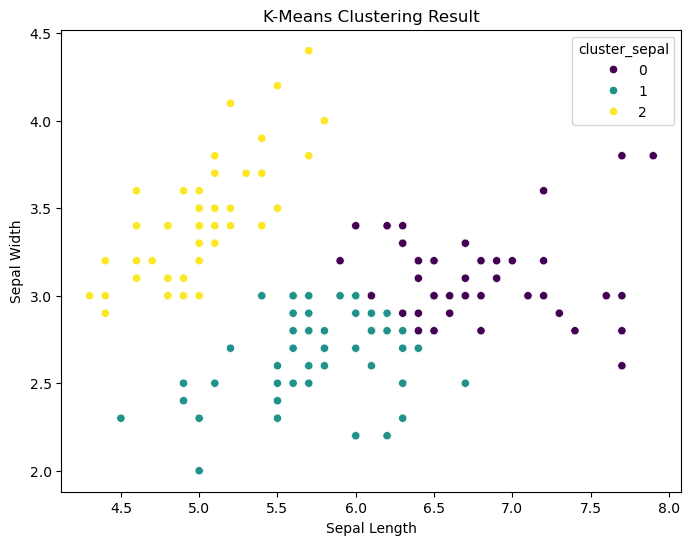

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["sepal_length"],
    y=df["sepal_width"],
    hue=df["cluster_sepal"],
    palette="viridis"
)
# "petal_length", "petal_width"
plt.title("K-Means Clustering Result")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

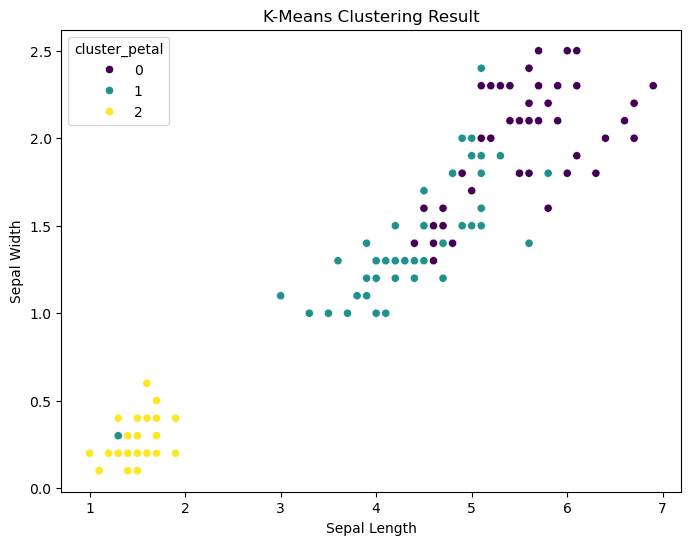

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["petal_length"],
    y=df["petal_width"],
    hue=df["cluster_petal"],
    palette="viridis"
)
# "petal_length", "petal_width"
plt.title("K-Means Clustering Result")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

## 🔹 Section 8: Finding Optimal k (Elbow Method)


In [34]:
#Finding Optimal k (Elbow Method)
inertia_values = []

k_range = range(1,11)

for k in k_range:
  km = KMeans(n_clusters=k, init="k-means++", random_state=42)
  km.fit(X_sepal_scaled)
  inertia_values.append(km.inertia_)

C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to 

In [36]:
inertia_values

[299.9999999999999,
 166.95170933934475,
 102.61686896314458,
 86.15796454443888,
 79.1388561408765,
 56.664733522618945,
 48.62356659768335,
 47.08313811353535,
 38.781508952596575,
 29.016791947131725]

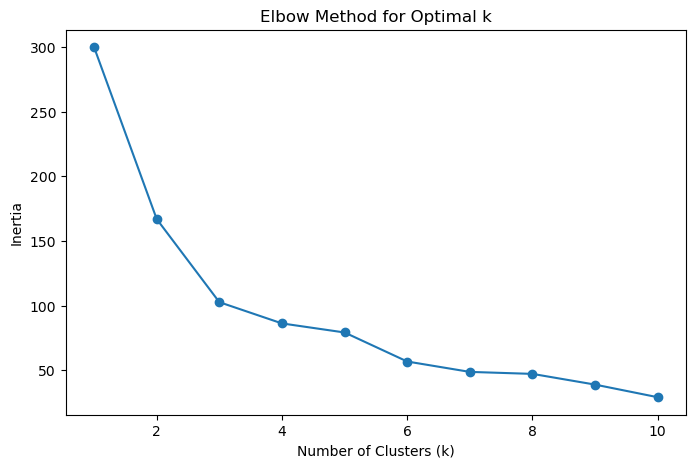

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

> The elbow is where improvement slows down.


## 🔹 Section 9: Model Evaluation (Silhouette Score)


In [42]:
score_sepal = silhouette_score(X_sepal_scaled, labels_sepal)
print("Silhouette Score:", score_sepal)

Silhouette Score: 0.43431274169892686


In [46]:
score_petal = silhouette_score(X_petal_scaled, labels_petal)
print("Silhouette Score:", score_petal)

Silhouette Score: 0.44554925904055664


In [54]:
df.info()
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

X_all_scalled =scaler.fit_transform(X)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sepal_length   150 non-null    float64
 1   sepal_width    150 non-null    float64
 2   petal_length   150 non-null    float64
 3   petal_width    150 non-null    float64
 4   species        150 non-null    object 
 5   cluster_sepal  150 non-null    int32  
 6   cluster_petal  150 non-null    int32  
dtypes: float64(4), int32(2), object(1)
memory usage: 7.2+ KB


In [56]:
inertia_values = []

k_range = range(1,11)

for k in k_range:
  km = KMeans(n_clusters=k, init="k-means++", random_state=42)
  km.fit(X_all_scalled)
  inertia_values.append(km.inertia_)

C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to 

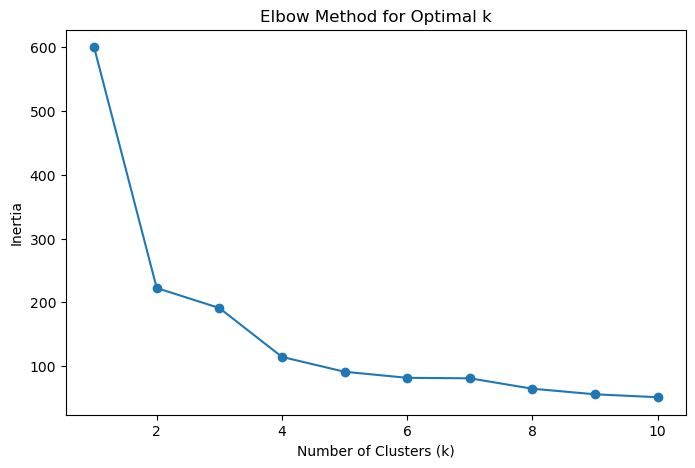

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [72]:
kmeans = KMeans(
    n_clusters=2,
    init="k-means++",
    max_iter=300,
    random_state=42
)
kmeans.fit(X_all_scalled)

C:\Users\ImranHossain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=2, random_state=42)

In [74]:
labels = kmeans.labels_

In [76]:
df["cluster"]=labels
df.head(150)

,sepal_length,sepal_width,petal_length,petal_width,species,cluster_sepal,cluster_petal,cluster
0,5.1,3.5,1.4,0.2,setosa,2,2,1
1,4.9,3.0,1.4,0.2,setosa,2,2,1
2,4.7,3.2,1.3,0.2,setosa,2,2,1
3,4.6,3.1,1.5,0.2,setosa,2,2,1
4,5.0,3.6,1.4,0.2,setosa,2,2,1
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,0,0,0
146,6.3,2.5,5.0,1.9,virginica,1,1,0
147,6.5,3.0,5.2,2.0,virginica,0,0,0
148,6.2,3.4,5.4,2.3,virginica,0,0,0


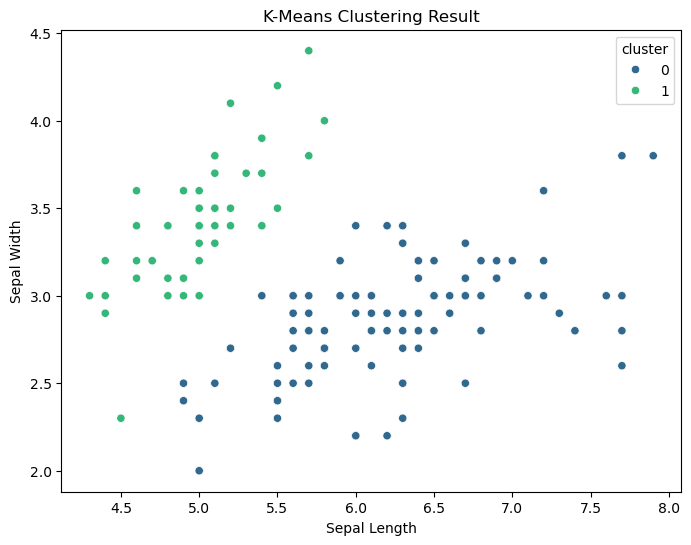

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["sepal_length"],
    y=df["sepal_width"],
    hue=df["cluster"],
    palette="viridis"
)

plt.title("K-Means Clustering Result")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

In [80]:
score = silhouette_score(X_all_scalled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5817500491982808


Interpretation guide:
- Above 0.5 → strong clustering
- Around 0.2–0.4 → overlapping clusters
- Near 0 → useless clustering


## 🔹 Section 10: Limitations of K-Means


In [ ]:
limitations = [
    "Requires choosing k manually",
    "Sensitive to feature scaling",
    "Fails with non-spherical clusters",
    "Sensitive to outliers",
    "Distance-based, not density-based"
]

for l in limitations:
    print("-", l)


## 🔹 Section 11: Real-World Use Cases

**Works well for:**
- Customer segmentation
- Image compression
- Market grouping
- Sensor data clustering

**Avoid using for:**
- Arbitrary-shaped clusters
- Highly skewed data
- Strong outliers


## 🔹 Section 12: Final Teaching Summary


In [84]:
print("""
Key Takeaways:
- K-Means finds structure, not truth
- Scaling is mandatory
- k must be chosen carefully
- Always visualize results
- Never trust clusters blindly
""")


Key Takeaways:
- K-Means finds structure, not truth
- Scaling is mandatory
- k must be chosen carefully
- Always visualize results
- Never trust clusters blindly

